In [1]:
from stark_qa import load_skb
import regex as re
import ast
import torch
import vss
from stark_qa import load_qa
import sys
from urllib import response
import os
import pandas as pd
import numpy as np
import json


OpenAI API key found.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

# print("OPENAI_API_KEY =", os.getenv("OPENAI_API_KEY"))
# print("NVIDIA_API_KEY =", os.getenv("NVIDIA_API_KEY"))


True

In [3]:
from custom_pipeline.entity_parsing import *
from custom_pipeline.relation_parsing import *
from custom_pipeline.llm_bridge import LlmBridge

In [4]:
data_split = 'test'

emb_model = 'text-embedding-ada-002'
configs_path = 'configs.json'

In [5]:
qa_dataset = load_qa('prime')
qa = qa_dataset.split_indices[data_split].reshape(-1).tolist()
# qa = qa[:int(len(qa) * 0.1)]
test_queries = [qa_dataset[i] for i in qa]

dataset_name = 'prime'
kb = load_skb(dataset_name, download_processed=True)


Use file from /home/sarthak/.cache/huggingface/hub/datasets--snap-stanford--stark/snapshots/88269e23e90587f99476c5dd74e235a0877e69be/qa/prime/stark_qa/stark_qa_human_generated_eval.csv.
Loading from /home/sarthak/.cache/huggingface/hub/datasets--snap-stanford--stark/snapshots/88269e23e90587f99476c5dd74e235a0877e69be/skb/prime/processed!


In [6]:
class Query:
    def __init__(self, query_id, query, ground_truths, entities, relations):
        self.query_id = query_id
        self.query = query
        self.ground_truths = ground_truths
        self.entities = entities
        self.relations = relations
        self.initial_symbol_candidates = {}
        self.answers = []
        self.answer_contexts = []
        self.evaluation_metrics = {}

    def __str__(self):
        return f"Query ID: {self.query_id}\nQuery: {self.query}\nGround Truth Answer: {self.ground_truth_answer}\nEntities: {self.entities}\nRelations: {self.relations}\nInitial Symbol Candidates: {self.initial_symbol_candidates}\nAnswers: {self.answers}\nAnswer Contexts: {self.answer_contexts}\nEvaluation Metrics: {self.evaluation_metrics}"

In [7]:
df = pd.read_csv('./STEP2_results/full_data_dump.csv',header=0)

queries = []

import json
import ast
import math
import re

def parse_mixed(val):
    # Already parsed dict
    if isinstance(val, dict):
        return val

    # NaN or None
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return {}

    s = str(val).strip()

    # Remove one outer layer of quotes
    if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
        s = s[1:-1].strip()

    # ---- Try JSON first ----
    try:
        return json.loads(s)
    except:
        pass

    # ---- Convert JSON tokens -> Python tokens ----
    # true -> True, false -> False, null -> None
    fixed = (
        s.replace("true", "True")
         .replace("false", "False")
         .replace("null", "None")
    )

    # ---- Try Python literal ----
    try:
        return ast.literal_eval(fixed)
    except:
        print("UNPARSABLE STRING:", repr(s))
        raise


for index, query in df.iterrows():
    # print(query)
    queries.append(Query(
        query_id = query['id'],
        query = query['query'],
        ground_truths = parse_mixed(query['ground_truths']),
        entities = parse_mixed(query['entities']),
        relations = parse_mixed(query['relations'])
    ))


In [8]:
current_query = queries[0]

In [9]:
## intermediate step : initializing VSS (fucntion definitions and all)


from custom_pipeline.vss_retreiver import VSSRetriever

# Initialize the retriever
retriever = VSSRetriever(
    kb=kb,
    emb_base_path="./emb/prime",
    emb_model="text-embedding-ada-002",
    qa_dataset=qa_dataset,
    dataset_name="test",
    use_vss=True  # Set to True if you need VSS object for generating new embeddings
)

# Now you can use the retriever
print("Available node types:", retriever.get_available_node_types())
# Retrieve top k nodes
top_nodes, scores = retriever.get_top_k_nodes(
    search_str="your query here",
    k=10,
    node_type="drug",
    cutoff=0.5
)

# Access the loaded embeddings if needed
entity_emb_dict = retriever.entity_emb_dict
query_emb_dict = retriever.query_emb_dict
candidate_emb_dict = retriever.candidate_emb_dict
node_emb_dict = retriever.node_emb_dict

Loading query embeddings from emb/prime/text-embedding-ada-002/query/query_emb_dict.pt.
Loaded 11204 query embeddings from emb/prime/text-embedding-ada-002/query/query_emb_dict.pt!
Loaded embeddings of nodes from emb/prime/text-embedding-ada-002/nodes!
Loaded 684 entity embeddings from emb/prime/text-embedding-ada-002/entities/entity_emb_dict.pt!
Available node types: ['biological_process', 'exposure', 'gene/protein', 'drug', 'pathway', 'effect/phenotype', 'anatomy', 'molecular_function', 'cellular_component', 'disease']
Getting embedding for query: your query here using model: text-embedding-ada-002


In [10]:
## Step 3 : getting initial candidates for all the symbols except answer 
from custom_pipeline.candidate_context import CandidateContext

def get_initial_candidates_for_entity(entity_info, entity_key, kb, retriever):
    print(entity_info)
    # entity_info = entity_info[entity_key]
    candidates = []
    entity_types = entity_info.get("type", [])
    name_constraint = entity_info.get("lexical", {}).get("name", None)
    semantic_constraints = entity_info.get("semantic", []).copy()
    # if len(semantic_constraints) == 0:   ## doing this because there was one node that had some phrase "a b c" , "a b" was identified as name, only c didn't make sense as lexical constraint
    #     semantic_constraints = []
    for key in entity_info.get("lexical", {}):
        semantic_constraints.append(f" {entity_info['lexical'][key]}")
   
    nodes_by_name = []

    if name_constraint:
        for etype in entity_types:
            # print("Searching for entity type:", etype)
            nodes_by_name = kb.get_node_ids_by_value(node_type=etype, key="name", value=name_constraint)
            # print("Found nodes by name:", nodes_by_name)
            candidates.extend([CandidateContext(node_id=x, entity=entity_key,score=1)for x in nodes_by_name])

    vss_candidates_count = 25 - len(candidates) # total 25 candidates instead of 20 

    for etype in entity_types : 
        sem = "".join(semantic_constraints)
        # print("Searching for semantic constraint:", sem)
        nodes_by_desc_ids , vss_scores = retriever.get_top_k_nodes(search_str=sem, k=vss_candidates_count, node_type=etype, cutoff=0.65) # adding a cutoff
        candidates.extend([CandidateContext(node_id=nodes_by_desc_ids[x], entity=entity_key,score=vss_scores[x])for x in range(len(nodes_by_desc_ids)) if nodes_by_desc_ids[x] not in nodes_by_name])
        # print("Found nodes by description:", len(nodes_by_desc_ids))
            # candidates.extend(nodes_by_desc)
    # print("Candidates so far:", candidates)
    return candidates # Remove duplicates


In [11]:
def step3_get_initial_candidates(current_query) : 
    initial_candidates = {}
    # print(initial_candidates)
    for entity in current_query.entities:
        # print("Entity:", entity)
        if entity == "ANSWER":
            continue
        initial_candidates[entity] = get_initial_candidates_for_entity(current_query.entities[entity],entity_key=entity,kb=kb,retriever=retriever)
    current_query.initial_symbol_candidates = initial_candidates

In [12]:
step3_get_initial_candidates(current_query)

{'type': ['drug'], 'lexical': {'name': 'Travoprost'}, 'semantic': ['Travoprost'], 'constant': True}
Getting embedding for query: Travoprost Travoprost using model: text-embedding-ada-002
{'type': ['gene/protein'], 'lexical': {}, 'semantic': ['influenced by the medication Travoprost'], 'constant': False}
Getting embedding for query: influenced by the medication Travoprost using model: text-embedding-ada-002


In [13]:
# Step 4 : Grounding

from custom_pipeline.grounders.original_grounder import PriorityQueueGrounding
import heapq
from typing import Dict, Set, List, Tuple
from collections import defaultdict
from custom_pipeline.candidate_context import CandidateContext
# from custom_pipeline.priority_queue_grounding import PriorityQueueGrounding


def run_priority_queue_grounding(
    query_obj,
    kb,
    vss_retriever,
    max_candidates_per_symbol: int = 1000,
    max_answer_candidates: int = 50,
    top_k_neighbors: int = 10,
    score_decay: float = 0.9,
    support_boost : float = 0.15 ,
    verbose: bool = False,
    ground_truths = None
) -> Dict[str, List[CandidateContext]]:
    """
    Convenience function to run priority queue-based grounding.
    
    Args:
        query_obj: Query class instance with entities, relations, and initial_symbol_candidates
        kb: Knowledge base object
        vss_retriever: VSSRetriever instance for scoring neighbors
        max_candidates_per_symbol: Max candidates per entity (default 1000)
        max_answer_candidates: Max candidates for ANSWER entity (default 100)
        top_k_neighbors: Number of top neighbors to add per expansion (default 10)
        score_decay: Score decay factor for propagation (default 0.9)
        verbose: Print detailed logs (default True)
    
    Returns:
        Dictionary mapping entity symbols to lists of CandidateContext objects
    """
    grounder = PriorityQueueGrounding(
        query_obj=query_obj,
        kb=kb,
        vss_retriever=vss_retriever,
        max_candidates_per_symbol=max_candidates_per_symbol,
        max_answer_candidates=max_answer_candidates,
        top_k_neighbors=top_k_neighbors,
        score_decay=score_decay,
        support_boost=support_boost,
        verbose=verbose
    )
    
    return grounder.ground(ground_truths=query_obj.ground_truths)

In [14]:
def step4_grounding(query: Query, kb, retriever):
    """
    Runs the new grounding pipeline and returns:
    - candidates (dict of lists of CandidateContext)
    - statistics (detailed run statistics)
    - answers (sorted ANSWER candidates)
    """

    result = run_priority_queue_grounding(
        query_obj=query,
        kb=kb,
        vss_retriever=retriever,
        ground_truths=query.ground_truths,   # NEW: passes GTs
        max_candidates_per_symbol=3000,      # like your old settings
        max_answer_candidates=50,
        top_k_neighbors=20,
        support_boost=0.35,                  # your tuned values
        score_decay=0.9,
        verbose=False
    )

    # unpack new structure
    candidates = result["candidates"]
    stats = result["statistics"]

    # sort ANSWER candidates by score (descending)
    if "ANSWER" in candidates and len(candidates["ANSWER"]) > 0:
        answers = sorted(candidates["ANSWER"], key=lambda x: x.score, reverse=True)
        answers = [c.node_id for c in answers]
    else:
        answers = []

    return {
        "query": query,
        "answers": answers,
        "candidates": candidates,
        "statistics": stats
    }


In [15]:
# result = step4_grounding(current_query, kb, retriever)

# candidates = result["candidates"]
# stats = result["statistics"]
# answers = result["answers"]


In [16]:
# print("Top ANSWER candidates:", len(answers))


In [17]:
# print("Grounding Statistics:")
# for key, value in stats.items():
#     print(f"{key}: {value}")    

In [18]:
## Multithreaded grounding 
temp_queries = queries
results = []



In [19]:
import threading
from queue import Queue
from tqdm import tqdm

NUM_THREADS = 8   # set number of worker threads you want

task_q = Queue()
result_q = Queue()
results = []

# ---------------- Worker Function --------------------
def worker():
    while True:
        query = task_q.get()
        if query is None:
            task_q.task_done()
            break

        step3_get_initial_candidates(query)
        result = step4_grounding(query, kb, retriever)
        result_q.put(result)

        task_q.task_done()

# ---------------- Writer Thread -----------------------
def writer(total_queries):
    pbar = tqdm(total=total_queries)

    processed = 0
    while processed < total_queries:
        item = result_q.get()
        results.append(item)
        processed += 1
        pbar.update(1)

# ---------------- Start Worker Threads ----------------
threads = []
for _ in range(NUM_THREADS):
    t = threading.Thread(target=worker)
    t.start()
    threads.append(t)

# ---------------- Start Writer Thread -----------------
writer_thread = threading.Thread(target=writer, args=(len(temp_queries),), daemon=True)
writer_thread.start()

# ---------------- Push Tasks --------------------------
for q in temp_queries:
    task_q.put(q)

# ---------------- Add Poison Pills to Stop Workers ----
for _ in range(NUM_THREADS):
    task_q.put(None)

# ---------------- Wait for All Tasks ------------------
task_q.join()
writer_thread.join()

# ---------------- Clean Exit for Worker Threads --------
for t in threads:
    t.join()


{'type': ['drug'], 'lexical': {'name': 'Travoprost'}, 'semantic': ['Travoprost'], 'constant': True}
{'type': ['anatomy'], 'lexical': {'name': 'pericardium'}, 'semantic': ['pericardium'], 'constant': True}
{'type': ['disease'], 'lexical': {'name': 'beriberi'}, 'semantic': ['beriberi'], 'constant': True}
{'type': ['gene/protein', 'molecular_function'], 'lexical': {'name': 'PI3K'}, 'semantic': ['regulatory component', 'PI3K'], 'constant': False}
{'type': ['anatomy'], 'lexical': {'name': 'breast tissue'}, 'semantic': ['supernumerary', 'breast tissue'], 'constant': False}
{'type': ['molecular_function', 'biological_process'], 'lexical': {'name': 'hyaluronan absorption and breakdown'}, 'semantic': ['hyaluronan absorption and breakdown'], 'constant': False}
{'type': ['gene/protein'], 'lexical': {'name': 'clathrin'}, 'semantic': ['clathrin'], 'constant': False}
{'type': ['molecular_function'], 'lexical': {'name': '7-methylguanosine cap hypermethylation'}, 'semantic': ['7-methylguanosine cap hy

  0%|          | 0/278 [00:00<?, ?it/s]

Getting embedding for query: pericardium pericardium using model: text-embedding-ada-002
Getting embedding for query: beriberi beriberi using model: text-embedding-ada-002
Getting embedding for query: hyaluronan absorption and breakdown hyaluronan absorption and breakdown using model: text-embedding-ada-002
Getting embedding for query: regulatory componentPI3K PI3K using model: text-embedding-ada-002
Getting embedding for query: clathrin clathrin using model: text-embedding-ada-002
{'type': ['gene/protein'], 'lexical': {}, 'semantic': ['influenced by the medication Travoprost'], 'constant': False}
Getting embedding for query: involved in interaction with genes or proteins using model: text-embedding-ada-002
{'type': ['drug'], 'lexical': {'name': 'Zopiclone'}, 'semantic': ['Zopiclone'], 'constant': True}
Getting embedding for query: breast tissue supernumerary breast tissue using model: text-embedding-ada-002
Getting embedding for query: Zopiclone Zopiclone using model: text-embedding-a

  0%|          | 1/278 [00:03<14:29,  3.14s/it]

{'type': ['drug'], 'lexical': {}, 'semantic': ['specified medication'], 'constant': False}
Getting embedding for query: specified medication using model: text-embedding-ada-002
Getting embedding for query: thalamus dorsal region ventral region thalamus using model: text-embedding-ada-002
{'type': ['gene/protein'], 'lexical': {'name': 'FAT3'}, 'semantic': ['FAT3'], 'constant': True}
Getting embedding for query: FAT3 FAT3 using model: text-embedding-ada-002
Getting embedding for query: involved in hyaluronan metabolism involved in signaling cascades either precedes or follows hyaluronan absorption and breakdown using model: text-embedding-ada-002
{'type': ['gene/protein', 'molecular_function'], 'lexical': {'name': 'FGFR1c'}, 'semantic': ['pathway', 'FGFR1c'], 'constant': False}
Getting embedding for query: pathwayFGFR1c FGFR1c using model: text-embedding-ada-002
{'type': ['gene/protein', 'molecular_function'], 'lexical': {}, 'semantic': ['play a role in the signaling pathways of blood cl

...

 97%|█████████▋| 270/278 [1:19:40<08:42, 65.29s/it]

{'type': ['disease', 'effect/phenotype'], 'lexical': {'name': 'cerebral folate transport issues'}, 'semantic': ['neurodegenerative conditions related to'], 'constant': False}
Getting embedding for query: neurodegenerative conditions related to cerebral folate transport issues using model: text-embedding-ada-002
{'type': ['disease', 'effect/phenotype'], 'lexical': {'name': 'isolated familial vitamin E deficiencies'}, 'semantic': ['diseases tied to'], 'constant': False}
Getting embedding for query: diseases tied to isolated familial vitamin E deficiencies using model: text-embedding-ada-002
Getting embedding for query: cerebral folate transport issues neurodegenerative conditions related to using model: text-embedding-ada-002
Getting embedding for query: isolated familial vitamin E deficiencies diseases tied to using model: text-embedding-ada-002
Getting embedding for query: neurodegenerative conditions related to cerebral folate transport issues related to isolated familial vitamin E de

 98%|█████████▊| 273/278 [2:05:35<1:05:08, 781.71s/it]

KeyboardInterrupt: 

100%|██████████| 278/278 [2:55:59<00:00, 37.98s/it]   


In [20]:
print(len(results))

273


In [ ]:
print(results[1])

{'query': <__main__.Query object at 0x7024ffbf4ed0>, 'answers': [14982, 15441, 15570, 14137, 15534, 15319, 15099, 15430, 15692, 17318, 15835, 15472, 15369, 15421, 15454, 14993, 17067, 20343, 16569, 20132, 15179, 14880, 20293, 15885, 20497, 14609, 14706, 14132, 14106, 14678, 20200, 16344, 16347, 15892, 20320, 20274, 16341, 14707, 14646, 20447, 20438, 20446], 'candidates': {'A': [CandidateContext(
  node_id=83811,
  entity=A,
  score=1,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=83810,
  entity=A,
  score=0.8158910274505615,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=39564,
  entity=A,
  score=0.814441978931427,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=36315,
  entity=A,
  score=0.8143970966339111,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=29820,
  entity=A,
  score=0.812254011631012,
  support=0,
  triplets=[],
  symbol_candidates

In [21]:
for res in results:
    print(len(res['answers']))

0
13
50
42
0
50
50
50
33
0
50
50
20
50
50
31
50
50
0
50
50
50
50
50
50
50
16
45
50
6
50
39
50
50
50
0
50
50
50
24
50
50
50
50
0
50
39
44
50
50
50
50
50
0
16
50
50
50
0
0
0
50
50
50
50
50
31
50
50
50
0
50
50
50
50
50
50
21
27
50
50
50
0
50
50
50
50
0
50
50
50
50
8
50
49
50
50
50
50
0
34
50
50
33
50
50
50
0
50
50
50
50
50
0
50
20
50
50
50
21
17
33
50
50
50
17
50
50
50
50
50
50
0
50
42
50
50
50
50
23
50
0
50
0
21
50
23
50
50
50
50
50
0
50
50
50
50
50
50
50
50
50
50
39
50
50
50
0
50
50
50
50
0
50
0
50
50
0
50
50
0
50
0
50
50
50
50
21
50
3
0
20
1
50
50
50
39
11
50
24
0
4
50
50
50
50
50
10
0
50
25
50
0
19
50
50
0
33
50
50
50
50
50
50
50
0
50
50
0
50
50
26
50
50
50
50
50
26
50
50
50
18
41
50
21
50
50
26
50
50
50
50
12
50
0
50
13
50
50
50
50
50
50
50
50
42
40
50
50
40
0
38
0


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
from collections import defaultdict

def aggregate_and_plot_grounding_results(
    results: List[Dict],
    save_plots: bool = False,
    plot_dir: str = "./plots"
) -> Dict:
    """
    Aggregate statistics and create plots from multiple grounding results.
    
    Args:
        results: List of result dicts, each containing:
            {
                'query': Query object (with ground_truths),
                'answers': List of answer node IDs,
                'candidates': Dict of candidates,
                'statistics': Statistics dict
            }
        save_plots: Whether to save plots to files
        plot_dir: Directory to save plots
    
    Returns:
        {
            'summary_df': DataFrame with key metrics,
            'recall_data': Dict with recall@k data,
            'plots': Dict with plot references
        }
    """
    
    # Filter out queries without statistics
    valid_results = [r for r in results if r.get('statistics') is not None]
    
    if not valid_results:
        print("No valid results with statistics found!")
        return None
    
    print(f"Processing {len(valid_results)} queries with statistics...")
    
    # Initialize aggregators
    all_recall_curves = []
    gt_found_percentages = []
    gt_found_counts = []
    total_gts = []
    rounds_per_query = []
    nodes_processed_per_query = []
    avg_nodes_per_entity_per_query = []
    
    # Ground truth stats
    all_initial_scores = []
    all_final_scores = []
    all_support_boosts = []
    all_score_improvements = []
    all_rounds_when_found = []
    all_queue_positions = []
    all_final_ranks = []
    
    # Score progression tracking
    score_progressions = defaultdict(list)  # {step: [scores]}
    
    # GTs found by round tracking
    gts_by_round = defaultdict(list)  # {round: [count_found_in_that_round]}
    
    # Missing GTs
    total_gts_all_queries = 0
    total_gts_found_all_queries = 0
    
    # Process each query
    for result in valid_results:
        query = result['query']
        stats = result['statistics']
        answers = result['answers']  # Sorted by score
        ground_truths = set(query.ground_truths)
        
        total_gts_all_queries += len(ground_truths)
        
        # Calculate recall@k for this query
        recall_curve = []
        for k in range(1, 50):
            top_k = set(answers[:k]) if k <= len(answers) else set(answers)
            recall = len(top_k & ground_truths) / len(ground_truths) if ground_truths else 0
            recall_curve.append(recall)
        all_recall_curves.append(recall_curve)
        
        # GT discovery stats
        gt_tracking = stats['ground_truth_tracking']
        found_gts = sum(1 for gt_stats in gt_tracking.values() if gt_stats['found'])
        total_gts.append(len(ground_truths))
        gt_found_counts.append(found_gts)
        gt_found_percentages.append(found_gts / len(ground_truths) if ground_truths else 0)
        
        total_gts_found_all_queries += found_gts
        
        # Global stats
        rounds_per_query.append(stats['global_stats']['total_rounds'])
        nodes_processed_per_query.append(stats['global_stats']['total_nodes_processed'])
        
        # Calculate average nodes per entity for this query
        per_symbol = stats['per_symbol']
        num_entities = len([e for e in per_symbol.keys() if e != 'ANSWER'])
        total_processed = sum(s['total_processed'] for s in per_symbol.values())
        avg_nodes_per_entity = total_processed / num_entities if num_entities > 0 else 0
        avg_nodes_per_entity_per_query.append(avg_nodes_per_entity)
        
        # Process each ground truth
        for gt_id, gt_stats in gt_tracking.items():
            if gt_stats['found']:
                # Only append non-None values
                if gt_stats['initial_score'] is not None:
                    all_initial_scores.append(gt_stats['initial_score'])
                if gt_stats['final_score'] is not None:
                    all_final_scores.append(gt_stats['final_score'])
                if gt_stats['support_boosts'] is not None:
                    all_support_boosts.append(gt_stats['support_boosts'])
                
                # Calculate improvement only if both scores are valid
                if (gt_stats['initial_score'] is not None and 
                    gt_stats['initial_score'] > 0 and 
                    gt_stats['final_score'] is not None):
                    improvement = ((gt_stats['final_score'] - gt_stats['initial_score']) / 
                                   gt_stats['initial_score'] * 100)
                    all_score_improvements.append(improvement)
                
                if gt_stats['added_in_round'] is not None:
                    all_rounds_when_found.append(gt_stats['added_in_round'])
                
                if gt_stats['queue_position_when_processed'] is not None:
                    all_queue_positions.append(gt_stats['queue_position_when_processed'])
                
                if gt_stats['final_rank'] is not None:
                    all_final_ranks.append(gt_stats['final_rank'])
                
                # Score progression
                for step, score in enumerate(gt_stats['score_progression']):
                    if score is not None:
                        score_progressions[step].append(score)
        
        # GTs found by round
        if 'ground_truths_found_by_round' in stats['global_stats']:
            for round_num, count in stats['global_stats']['ground_truths_found_by_round'].items():
                gts_by_round[round_num].append(count)
    
    # Calculate aggregate statistics
    summary_stats = {
        'total_queries': len(valid_results),
        'avg_pct_gts_found': np.mean(gt_found_percentages) * 100 if gt_found_percentages else 0,
        'avg_gts_per_query': np.mean(total_gts) if total_gts else 0,
        'avg_gts_found_per_query': np.mean(gt_found_counts) if gt_found_counts else 0,
        'overall_pct_gts_found': (total_gts_found_all_queries / total_gts_all_queries * 100) 
                                  if total_gts_all_queries > 0 else 0,
        'avg_round_when_found': np.mean(all_rounds_when_found) if all_rounds_when_found else 0,
        'avg_queue_position': np.mean(all_queue_positions) if all_queue_positions else 0,
        'avg_initial_score': np.mean(all_initial_scores) if all_initial_scores else 0,
        'avg_final_score': np.mean(all_final_scores) if all_final_scores else 0,
        'avg_support_boosts': np.mean(all_support_boosts) if all_support_boosts else 0,
        'avg_score_improvement_pct': np.mean(all_score_improvements) if all_score_improvements else 0,
        'avg_rounds_per_query': np.mean(rounds_per_query) if rounds_per_query else 0,
        'avg_nodes_processed_per_query': np.mean(nodes_processed_per_query) if nodes_processed_per_query else 0,
        'avg_nodes_per_entity_per_query': np.mean(avg_nodes_per_entity_per_query) if avg_nodes_per_entity_per_query else 0,
    }
    
    summary_df = pd.DataFrame([summary_stats])
    
    # Calculate average recall@k
    avg_recall_curve = np.mean(all_recall_curves, axis=0) if all_recall_curves else [0] * 50
    recall_data = {
        'k_values': list(range(1, 50)),
        'avg_recall': avg_recall_curve.tolist(),
        'all_curves': all_recall_curves
    }
    
    # Average score progression
    max_steps = max(score_progressions.keys()) if score_progressions else 0
    avg_score_progression = []
    for step in range(max_steps + 1):
        if step in score_progressions and score_progressions[step]:
            avg_score_progression.append(np.mean(score_progressions[step]))
        else:
            avg_score_progression.append(None)
    
    # Average GTs found by round
    max_round = max(gts_by_round.keys()) if gts_by_round else 0
    avg_gts_by_round = []
    for round_num in range(1, max_round + 1):
        if round_num in gts_by_round and gts_by_round[round_num]:
            avg_gts_by_round.append(np.mean(gts_by_round[round_num]))
        else:
            avg_gts_by_round.append(0)
    
    # Create plots
    plots = {}
    
    # Set style
    sns.set_style("whitegrid")
    
    # 1. Recall@k vs k
    plt.figure(figsize=(12, 6))
    plt.plot(recall_data['k_values'], recall_data['avg_recall'], linewidth=2, label='Average Recall')
    
    # Mark specific k values
    for k in [20, 50, 100]:
        if k <= len(recall_data['avg_recall']):
            recall_at_k = recall_data['avg_recall'][k-1]
            plt.scatter([k], [recall_at_k], s=100, zorder=5, color='red')
            plt.annotate(f'R@{k}={recall_at_k:.3f}', 
                         xy=(k, recall_at_k), 
                         xytext=(10, -10),
                         textcoords='offset points',
                         fontsize=9,
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.xlabel('k (Number of Top Candidates)', fontsize=12)
    plt.ylabel('Recall@k', fontsize=12)
    plt.title('Average Recall@k Across All Queries', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    if save_plots:
        plt.savefig(f"{plot_dir}/recall_at_k.png", dpi=300, bbox_inches='tight')
    plots['recall_at_k'] = plt.gcf()
    plt.show()
    
    # 2. Distribution: GTs found per query (with outlier removal)
    if gt_found_counts:
        plt.figure(figsize=(10, 6))
        q1, q3 = np.percentile(gt_found_counts, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        gt_found_filtered = [x for x in gt_found_counts if lower_bound <= x <= upper_bound]
        outliers_removed = len(gt_found_counts) - len(gt_found_filtered)
        
        plt.hist(gt_found_filtered, bins=20, edgecolor='black', alpha=0.7)
        plt.xlabel('Number of Ground Truths Found', fontsize=12)
        plt.ylabel('Number of Queries', fontsize=12)
        plt.title(f'Distribution of Ground Truths Found Per Query\n({outliers_removed} outliers removed)', 
                  fontsize=14, fontweight='bold')
        if gt_found_filtered:
            plt.axvline(np.mean(gt_found_filtered), color='red', linestyle='--', 
                        linewidth=2, label=f'Mean = {np.mean(gt_found_filtered):.2f}')
            plt.legend()
        if save_plots:
            plt.savefig(f"{plot_dir}/gts_found_distribution.png", dpi=300, bbox_inches='tight')
        plots['gts_found_dist'] = plt.gcf()
        plt.show()
    
    # 3. Distribution: Rounds per query (with outlier removal)
    if rounds_per_query:
        plt.figure(figsize=(10, 6))
        q1, q3 = np.percentile(rounds_per_query, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        rounds_filtered = [x for x in rounds_per_query if lower_bound <= x <= upper_bound]
        outliers_removed = len(rounds_per_query) - len(rounds_filtered)
        
        plt.hist(rounds_filtered, bins=20, edgecolor='black', alpha=0.7, color='green')
        plt.xlabel('Number of Rounds', fontsize=12)
        plt.ylabel('Number of Queries', fontsize=12)
        plt.title(f'Distribution of Grounding Rounds Per Query\n({outliers_removed} outliers removed)', 
                  fontsize=14, fontweight='bold')
        if rounds_filtered:
            plt.axvline(np.mean(rounds_filtered), color='red', linestyle='--', 
                        linewidth=2, label=f'Mean = {np.mean(rounds_filtered):.2f}')
            plt.legend()
        if save_plots:
            plt.savefig(f"{plot_dir}/rounds_distribution.png", dpi=300, bbox_inches='tight')
        plots['rounds_dist'] = plt.gcf()
        plt.show()
    
    # 4. Distribution: Nodes processed per query (with outlier removal)
    if avg_nodes_per_entity_per_query:
        plt.figure(figsize=(10, 6))
        q1, q3 = np.percentile(avg_nodes_per_entity_per_query, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        nodes_filtered = [x for x in avg_nodes_per_entity_per_query if lower_bound <= x <= upper_bound]
        outliers_removed = len(avg_nodes_per_entity_per_query) - len(nodes_filtered)
        
        plt.hist(nodes_filtered, bins=20, edgecolor='black', alpha=0.7, color='purple')
        plt.xlabel('Average Nodes Processed Per Entity', fontsize=12)
        plt.ylabel('Number of Queries', fontsize=12)
        plt.title(f'Distribution of Avg Nodes Processed Per Entity Per Query\n({outliers_removed} outliers removed)', 
                  fontsize=14, fontweight='bold')
        if nodes_filtered:
            plt.axvline(np.mean(nodes_filtered), color='red', linestyle='--', 
                        linewidth=2, label=f'Mean = {np.mean(nodes_filtered):.2f}')
            plt.legend()
        if save_plots:
            plt.savefig(f"{plot_dir}/nodes_per_entity_distribution.png", dpi=300, bbox_inches='tight')
        plots['nodes_dist'] = plt.gcf()
        plt.show()
    
    # 5. Box plot: Support boosts (with outlier removal)
    if all_support_boosts:
        plt.figure(figsize=(8, 6))
        q1, q3 = np.percentile(all_support_boosts, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        boosts_filtered = [x for x in all_support_boosts if lower_bound <= x <= upper_bound]
        outliers_removed = len(all_support_boosts) - len(boosts_filtered)
        
        if boosts_filtered:
            plt.boxplot(boosts_filtered, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
            plt.ylabel('Number of Support Boosts', fontsize=12)
            plt.title(f'Distribution of Support Boosts for Found Ground Truths\n({outliers_removed} outliers removed)', 
                      fontsize=14, fontweight='bold')
            plt.grid(True, alpha=0.3, axis='y')
            if save_plots:
                plt.savefig(f"{plot_dir}/support_boosts_boxplot.png", dpi=300, bbox_inches='tight')
            plots['support_boosts'] = plt.gcf()
            plt.show()
    
    # 6. Line plot: Average score progression
    if avg_score_progression and any(x is not None for x in avg_score_progression):
        plt.figure(figsize=(10, 6))
        steps = list(range(len(avg_score_progression)))
        # Filter out None values for plotting
        valid_points = [(s, v) for s, v in zip(steps, avg_score_progression) if v is not None]
        if valid_points:
            steps_valid, scores_valid = zip(*valid_points)
            plt.plot(steps_valid, scores_valid, marker='o', linewidth=2, markersize=8)
            plt.xlabel('Update Step', fontsize=12)
            plt.ylabel('Average Score', fontsize=12)
            plt.title('Average Score Progression for Ground Truths', fontsize=14, fontweight='bold')
            plt.grid(True, alpha=0.3)
            if save_plots:
                plt.savefig(f"{plot_dir}/score_progression.png", dpi=300, bbox_inches='tight')
            plots['score_progression'] = plt.gcf()
            plt.show()
    
    # 7. Line plot: GTs found by round (averaged)
    if avg_gts_by_round:
        plt.figure(figsize=(10, 6))
        rounds = list(range(1, len(avg_gts_by_round) + 1))
        plt.plot(rounds, avg_gts_by_round, marker='o', linewidth=2, markersize=8, color='orange')
        plt.xlabel('Round Number', fontsize=12)
        plt.ylabel('Average Ground Truths Found', fontsize=12)
        plt.title('Average Ground Truths Found Per Round', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        if save_plots:
            plt.savefig(f"{plot_dir}/gts_by_round.png", dpi=300, bbox_inches='tight')
        plots['gts_by_round'] = plt.gcf()
        plt.show()
    
    # 8. Scatter: Queue position vs Final rank
    paired_data = []
    for result in valid_results:
        stats = result['statistics']
        for gt_id, gt_stats in stats['ground_truth_tracking'].items():
            if (gt_stats['found'] and 
                gt_stats['queue_position_when_processed'] is not None and 
                gt_stats['final_rank'] is not None):
                paired_data.append((
                    gt_stats['queue_position_when_processed'],
                    gt_stats['final_rank']
                ))

    if paired_data:
        queue_positions, final_ranks = zip(*paired_data)
        
        plt.figure(figsize=(10, 8))
        plt.scatter(queue_positions, final_ranks, alpha=0.6, s=50)
        plt.xlabel('Queue Position When Source Processed', fontsize=12)
        plt.ylabel('Final Rank in ANSWER Candidates', fontsize=12)
        plt.title('Queue Position vs Final Rank for Found Ground Truths', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Add trend line
        if len(queue_positions) > 1:
            z = np.polyfit(queue_positions, final_ranks, 1)
            p = np.poly1d(z)
            plt.plot(sorted(queue_positions), p(sorted(queue_positions)), 
                    "r--", alpha=0.8, linewidth=2, label='Trend')
            plt.legend()
        
        if save_plots:
            plt.savefig(f"{plot_dir}/queue_position_vs_rank.png", dpi=300, bbox_inches='tight')
        plots['queue_vs_rank'] = plt.gcf()
        plt.show()
    
    # Print summary
    print("\n" + "="*80)
    print("GROUNDING PERFORMANCE SUMMARY")
    print("="*80)
    print(summary_df.T)
    print("="*80)
    
    return {
        'summary_df': summary_df,
        'recall_data': recall_data,
        'plots': plots,
        'raw_data': {
            'gt_found_percentages': gt_found_percentages,
            'all_support_boosts': all_support_boosts,
            'all_score_improvements': all_score_improvements,
            'avg_score_progression': avg_score_progression,
            'avg_gts_by_round': avg_gts_by_round,
        }
    }

Processing 274 queries with statistics...


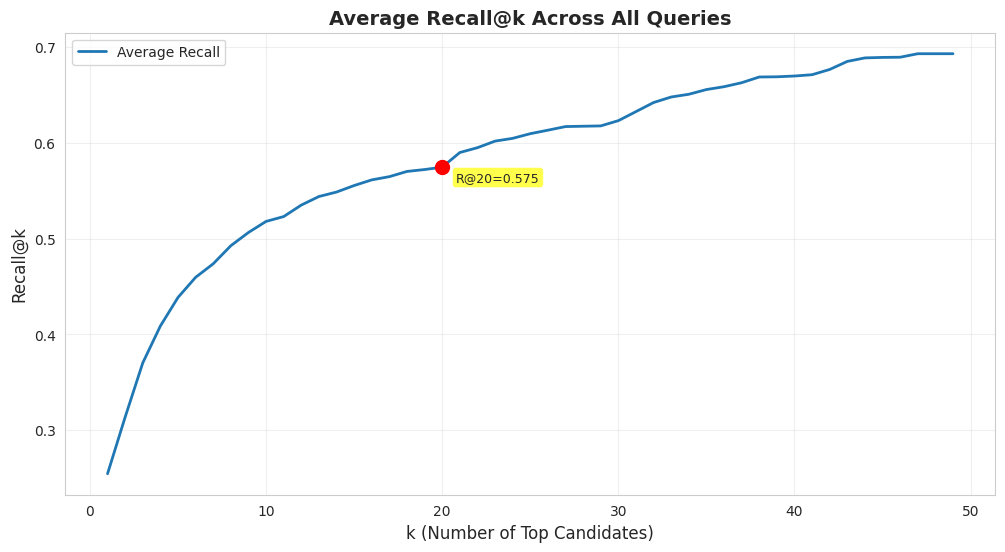

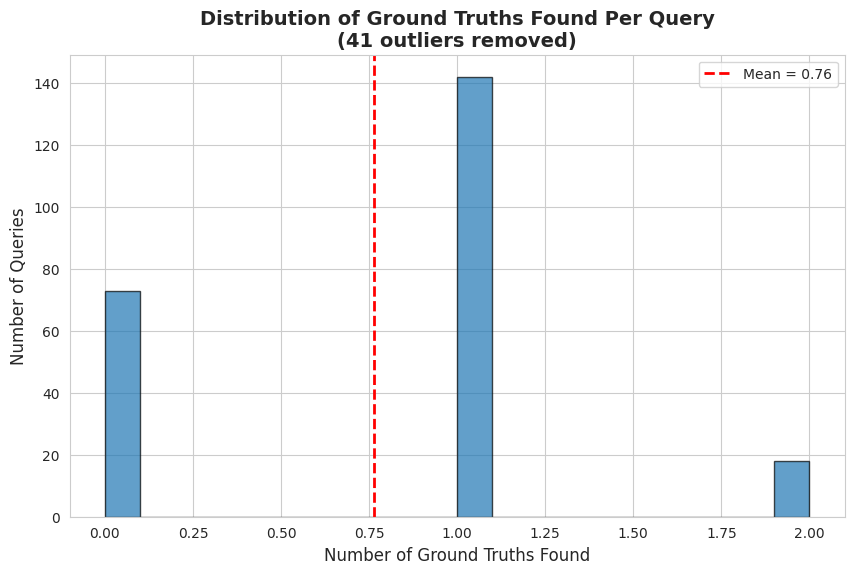

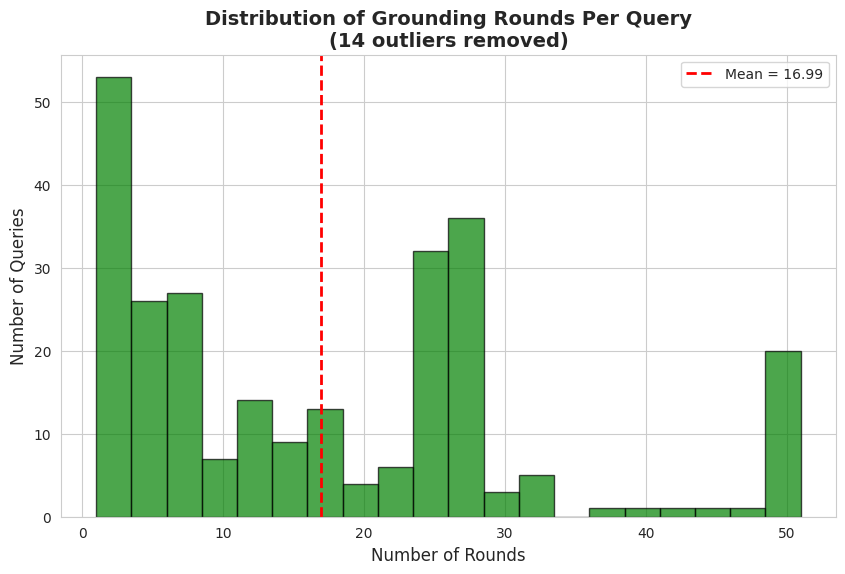

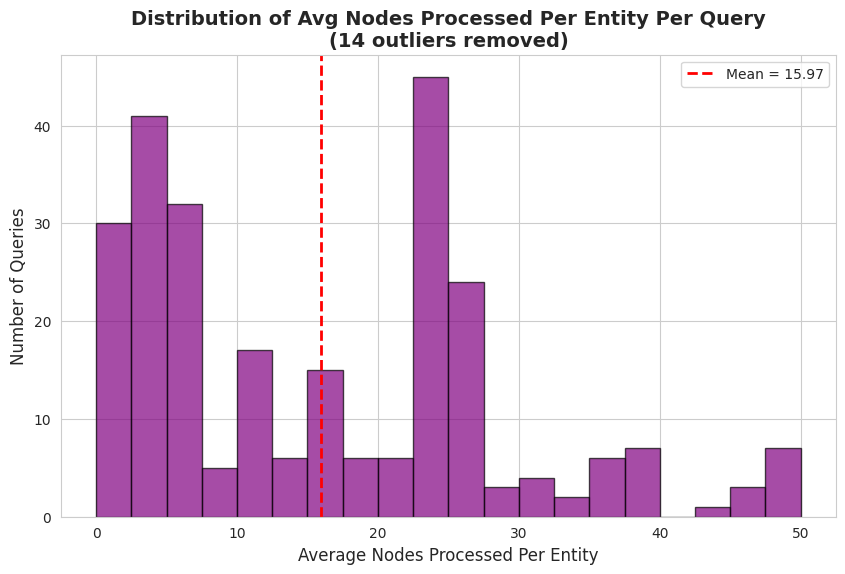

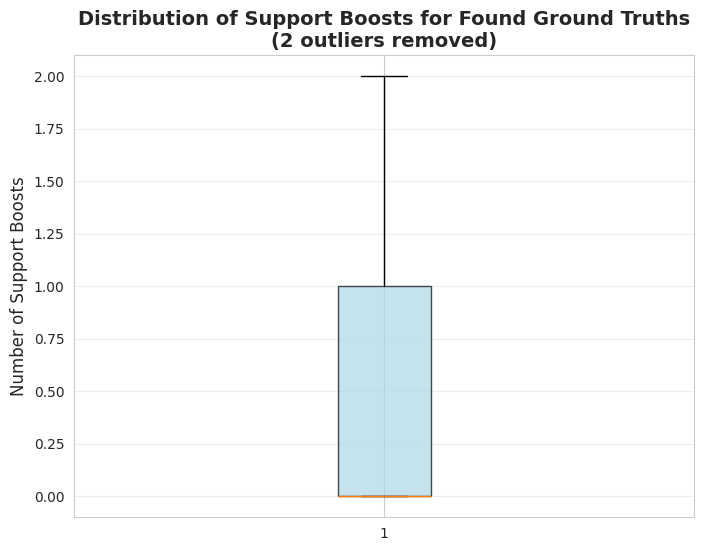

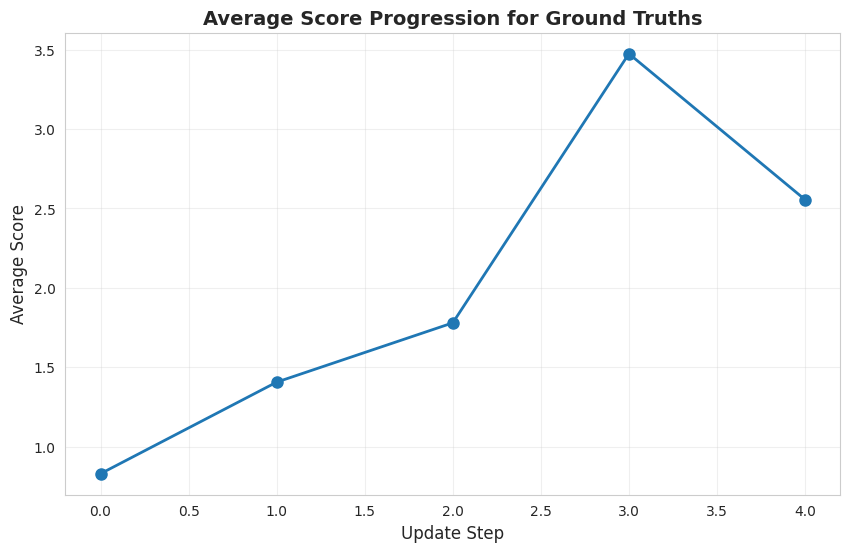

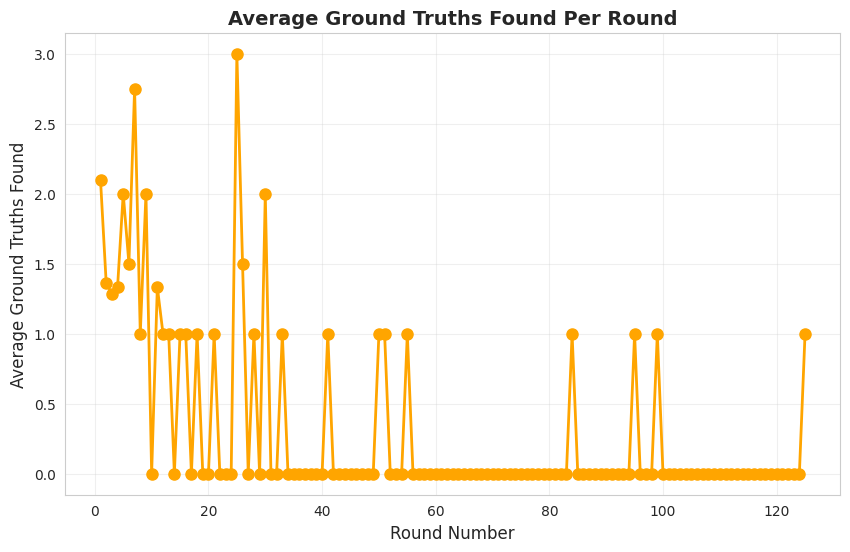

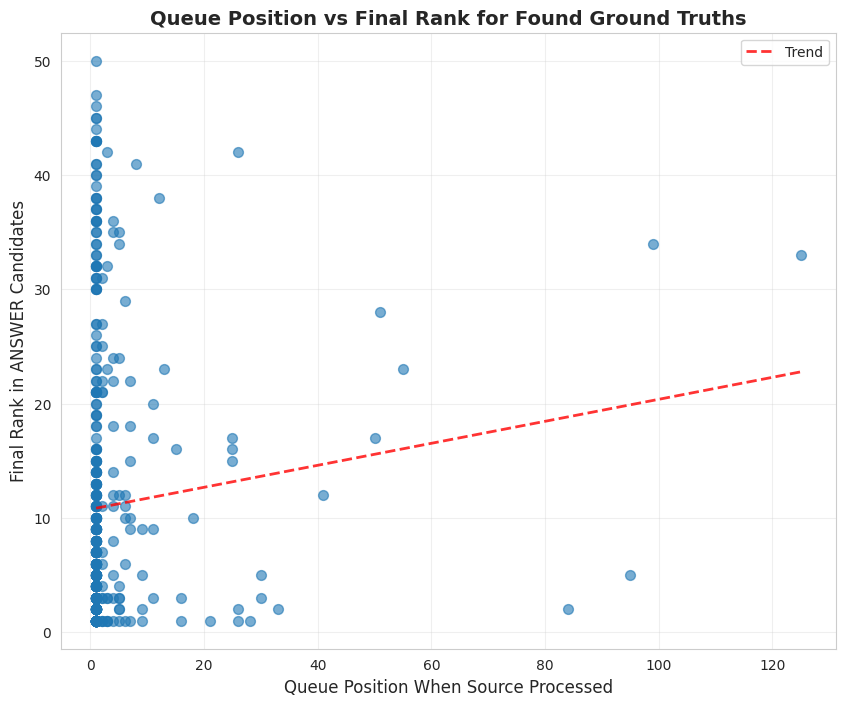


GROUNDING PERFORMANCE SUMMARY
                                         0
total_queries                   274.000000
avg_pct_gts_found                70.007143
avg_gts_per_query                 2.514599
avg_gts_found_per_query           1.580292
overall_pct_gts_found            62.844702
avg_round_when_found              3.872979
avg_queue_position                3.872979
avg_initial_score                 0.829520
avg_final_score                   0.997580
avg_support_boosts                0.323326
avg_score_improvement_pct        19.754296
avg_rounds_per_query             48.167883
avg_nodes_processed_per_query    76.222628
avg_nodes_per_entity_per_query   36.008212


In [29]:
aggregation_results = aggregate_and_plot_grounding_results(results, save_plots=False)

In [30]:
print(aggregation_results['recall_data'].keys())
for rec in range(50):
    print(aggregation_results['recall_data']['k_values'][rec], aggregation_results['recall_data']['avg_recall'][rec])
    

dict_keys(['k_values', 'avg_recall', 'all_curves'])
1 0.25466030320044925
2 0.3137986506599645
3 0.37032879934339785
4 0.40884381231096556
5 0.4386141838696583
6 0.459605155590557
7 0.47374292374292365
8 0.4925904590138167
9 0.5063835394127364
10 0.517946287289353
11 0.5229934096722417
12 0.535002224053319
13 0.5439193409996329
14 0.5485785504033679
15 0.5553736004465932
16 0.5612825333628253
17 0.5646454113607398
18 0.5700937950937951
19 0.5720679158635363
20 0.5745618331384755
21 0.5898419149787762
22 0.5948573982789311
23 0.601730877597666
24 0.6046174071265313
25 0.6094835871751931
26 0.6131332222116894
27 0.6169045117494023
28 0.617269475253052
29 0.6176012602563697
30 0.6230757128111143
31 0.6325039366553965
32 0.6419828498751856
33 0.6477614386829715
34 0.6506145263900739
35 0.6555313958142426
36 0.6585061380225613
37 0.6626626668141267
38 0.6686440131239403
39 0.6688467706259678
40 0.6696578006340781
41 0.6710264137727641
42 0.6765008663275086
43 0.6849153026616529
44 0.6885649

IndexError: list index out of range

In [ ]:
import pickle

with open('grounding_results_3000_50_20_0.35_0.9.pkl', 'wb') as f:
    pickle.dump(results, f)

In [31]:
results[0]

{'query': <__main__.Query at 0x7ba736f1c910>,
 'answers': [],
 'candidates': {'A': [CandidateContext(
     node_id=73859,
     entity=A,
     score=0.8264324069023132,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
   CandidateContext(
     node_id=73414,
     entity=A,
     score=0.8236507177352905,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
   CandidateContext(
     node_id=76047,
     entity=A,
     score=0.8232007026672363,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
   CandidateContext(
     node_id=63266,
     entity=A,
     score=0.819764256477356,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
   CandidateContext(
     node_id=65855,
     entity=A,
     score=0.8185624480247498,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
   CandidateContext(
     node_id=68861,
     entity=A,
     score=0.8129784464836121,
     support=0,
     triplets=[],
     symbol_candidates={}
   ),
  